In [ ]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [24]:
# 노트북 맨 위에 한 번만 실행
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'

plt.rcParams['axes.unicode_minus'] = False

# 이제 모든 그래프에서 한글 사용 가능

In [2]:
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')
submission = pd.read_csv('../data/sample_submission.csv')

In [5]:
def engineer_features(df):
    """피처 엔지니어링 함수"""
    df = df.copy()
    
    # 2.1 Age
    df['age_squared'] = df['Age'] ** 2
    df['age_40_60'] = ((df['Age'] >= 40) & (df['Age'] <= 60)).astype(int)
    
    # 2.4 Cholesterol
    df['chol_capped'] = df['Cholesterol'].clip(upper=320)
    df['chol_peak'] = ((df['Cholesterol'] >= 280) & (df['Cholesterol'] <= 320)).astype(int)
    
    # 2.6 MaxHR
    df['maxhr_inv'] = 1 / (df['Max HR'] + 1)
    df['maxhr_high'] = (df['Max HR'] >= 150).astype(int)
    
    # 2.7 STdepression
    df['st_log'] = np.log1p(df['ST depression'])
    df['st_abnormal'] = (df['ST depression'] > 0).astype(int)
    
    return df

# 적용
train_df = engineer_features(train_df)
test_df = engineer_features(test_df)

# replace를 타겟 피처 이진화
train_df['Heart Disease'] = train_df['Heart Disease'].replace({'Presence': 1, 'Absence': 0})
train_df['Heart Disease'] = train_df['Heart Disease'].astype(int)

In [4]:
X = train_df.drop('Heart Disease',axis=1)
y = train_df['Heart Disease']

## 2. 모델링
- 하이퍼파라미터 튜닝
    1. XGBoost - Optuna 100 trials
    2. LightGBM - Optuna 100 trials  
    3. RandomForest - Optuna 50 trials
    4. Logistic - GridSearch (빠르게)

2. 앙상블 (Voting/Averaging)
   - 상관관계 보고 3개 선정
   - 가중 평균으로 예측

3. 스태킹
   - Base Models: 위 4개 전부 사용 (또는 3개)
   - Meta Model: 간단한 모델 (Logistic, Ridge 등)

- **cv기반 스태킹 앙상블진행**

#### 2.1.1 XGBoost 단일모델

In [6]:
import optuna
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [8]:
def objective_xgb(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'colsample_bynode': trial.suggest_float('colsample_bynode', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        'random_state': 42,
        'eval_metric': 'logloss'
    }
    
    model = XGBClassifier(**params)
    score = cross_val_score(model, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
    
    return score.mean()

print("=" * 50)
print("XGBoost 하이퍼파라미터 튜닝 시작 (100 trials)")
print("=" * 50)

study_xgb = optuna.create_study(direction='maximize', study_name='XGBoost')
#create_study() : 최적화 학습 생성
#direction : 최적화 방향 -> maximize 최대화하기 

study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)
#optimize() : 최적화 실행
#n_trails : 100회 시도
#shoW_progress_bar : 진행상황 표시


print(f"\nXGBoost 최적 점수: {study_xgb.best_value:.4f}")
print(f"XGBoost 최적 파라미터:\n{study_xgb.best_params}")

[I 2026-02-16 12:48:22,134] A new study created in memory with name: XGBoost


XGBoost 하이퍼파라미터 튜닝 시작 (100 trials)


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-02-16 12:48:39,849] Trial 0 finished with value: 0.9550275228945985 and parameters: {'max_depth': 7, 'learning_rate': 0.1778512943907835, 'n_estimators': 117, 'min_child_weight': 3, 'subsample': 0.8121110081507605, 'colsample_bytree': 0.5260841410465551, 'colsample_bylevel': 0.8321535590465859, 'colsample_bynode': 0.6801144228310201, 'gamma': 1.9282567625455833, 'reg_alpha': 5.05903575446263, 'reg_lambda': 1.6901439935468565}. Best is trial 0 with value: 0.9550275228945985.
[I 2026-02-16 12:49:12,272] Trial 1 finished with value: 0.9540916130434212 and parameters: {'max_depth': 7, 'learning_rate': 0.17558720258192992, 'n_estimators': 283, 'min_child_weight': 3, 'subsample': 0.6393401538120895, 'colsample_bytree': 0.7437968228887133, 'colsample_bylevel': 0.9512867718594946, 'colsample_bynode': 0.5441377783865948, 'gamma': 0.8020686699219948, 'reg_alpha': 2.980241424746699, 'reg_lambda': 2.442714166252048}. Best is trial 0 with value: 0.9550275228945985.
[I 2026-02-16 12:49:21,35

#### 2.1.2 LightGBM 단일모델
##### XGBoost 코드 대비 개선점
1. 파라미터 범위조정
    - Regularization 파라미터 범위는 작은 값이 더 중요하므로, 0~10 균등분포보다는 로그 스케일로 적용
2. optuna.creat_stduy() 하이퍼 파라미터 추가
    - TPEsampler : 똑똑한 탐색, MedianPruner : 안좋은 trial 조기종료 -> 시간 절약 

In [12]:
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
import optuna

def objective_lgbm(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'verbose': -1
    }
    
    model = LGBMClassifier(**params)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    scores = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model.fit(X_train, y_train)
        score = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
        scores.append(score)
        
        trial.report(score, fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return sum(scores) / len(scores)

print("\n" + "=" * 50)
print("LightGBM 하이퍼파라미터 튜닝 시작 (100 trials)")
print("=" * 50)

study_lgbm = optuna.create_study(
    direction='maximize',
    study_name='LightGBM',
    sampler=optuna.samplers.TPESampler(n_startup_trials=10, seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0)
)

study_lgbm.optimize(objective_lgbm, n_trials=100, show_progress_bar=True)

print(f"\nLightGBM 최적 점수: {study_lgbm.best_value:.4f}")
print(f"LightGBM 최적 파라미터:\n{study_lgbm.best_params}")

[I 2026-02-16 13:40:04,712] A new study created in memory with name: LightGBM



LightGBM 하이퍼파라미터 튜닝 시작 (100 trials)


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-02-16 13:41:00,255] Trial 0 finished with value: 0.9547149964111732 and parameters: {'max_depth': 9, 'num_leaves': 144, 'learning_rate': 0.1205712628744377, 'n_estimators': 200, 'min_child_samples': 19, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'reg_alpha': 0.6245760287469887, 'reg_lambda': 0.002570603566117596}. Best is trial 0 with value: 0.9547149964111732.
[I 2026-02-16 13:41:28,213] Trial 1 finished with value: 0.954627095963958 and parameters: {'max_depth': 12, 'num_leaves': 22, 'learning_rate': 0.27081608642499677, 'n_estimators': 258, 'min_child_samples': 25, 'subsample': 0.5909124836035503, 'colsample_bytree': 0.5917022549267169, 'reg_alpha': 5.472429642032189e-06, 'reg_lambda': 0.00052821153945323}. Best is trial 0 with value: 0.9547149964111732.
[I 2026-02-16 13:41:45,083] Trial 2 finished with value: 0.9543378524176896 and parameters: {'max_depth': 9, 'num_leaves': 58, 'learning_rate': 0.08012737503998542, 'n_estimators': 85, 'min_chil

In [13]:
def objective_rf_advanced(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),  # 범위 확대
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.1),
        'bootstrap': True,
        'max_samples': trial.suggest_float('max_samples', 0.5, 1.0),  # 샘플링 비율
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', None]),  # 불균형 대응
        'random_state': 42,
        'n_jobs': 1
    }
    
    model = RandomForestClassifier(**params)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    scores = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model.fit(X_train, y_train)
        score = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
        scores.append(score)
        
        trial.report(score, fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return sum(scores) / len(scores)

study_rf = optuna.create_study(
    direction='maximize',
    study_name='RandomForest',
    sampler=optuna.samplers.TPESampler(n_startup_trials=5, seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=0)
)

study_rf.optimize(objective_rf_advanced, n_trials=50, show_progress_bar=True)

[I 2026-02-16 14:04:12,753] A new study created in memory with name: RandomForest


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-02-16 14:08:00,021] Trial 0 finished with value: 0.9437289264667832 and parameters: {'n_estimators': 250, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'min_impurity_decrease': 0.005808361216819946, 'max_samples': 0.9330880728874675, 'class_weight': None}. Best is trial 0 with value: 0.9437289264667832.
[I 2026-02-16 14:09:06,174] Trial 1 finished with value: 0.9369394451009059 and parameters: {'n_estimators': 108, 'max_depth': 30, 'min_samples_split': 17, 'min_samples_leaf': 3, 'max_features': 'log2', 'min_impurity_decrease': 0.030424224295953775, 'max_samples': 0.762378215816119, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9437289264667832.
[I 2026-02-16 14:12:53,139] Trial 2 finished with value: 0.9417863374407658 and parameters: {'n_estimators': 345, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'log2', 'min_impurity_decrease': 0.019967378215835975, 'max_samples': 0.7571172192068059, 

In [14]:
print("\n" + "=" * 50)
print("최종 결과 요약")
print("=" * 50)
print(f"XGBoost    - 최적 : {study_xgb.best_value:.4f}")
print(f"LightGBM   - 최적 : {study_lgbm.best_value:.4f}")
print(f"RandomForest - 최적 : {study_rf.best_value:.4f}")

# 최고 성능 모델 확인
best_scores = {
    'XGBoost': study_xgb.best_value,
    'LightGBM': study_lgbm.best_value,
    'RandomForest': study_rf.best_value
}
best_model_name = max(best_scores, key=best_scores.get)
print(f"\n최고 성능 모델: {best_model_name} ({best_scores[best_model_name]:.4f})")



최종 결과 요약
XGBoost    - 최적 : 0.9553
LightGBM   - 최적 : 0.9553
RandomForest - 최적 : 0.9502

최고 성능 모델: LightGBM (0.9553)


In [15]:
print("\n" + "=" * 50)
print("최적 파라미터로 최종 모델 학습")
print("=" * 50)

# XGBoost 최종 모델
final_xgb = XGBClassifier(**study_xgb.best_params)
final_xgb.fit(X, y)
print("✓ XGBoost 최종 모델 학습 완료")

# LightGBM 최종 모델
final_lgbm = LGBMClassifier(**study_lgbm.best_params)
final_lgbm.fit(X, y)
print("✓ LightGBM 최종 모델 학습 완료")

# RandomForest 최종 모델
final_rf = RandomForestClassifier(**study_rf.best_params)
final_rf.fit(X, y)
print("✓ RandomForest 최종 모델 학습 완료")


최적 파라미터로 최종 모델 학습
✓ XGBoost 최종 모델 학습 완료
✓ LightGBM 최종 모델 학습 완료
✓ RandomForest 최종 모델 학습 완료


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

# =============================================================================
# Stacking 앙상블 구현
# =============================================================================

print("\n" + "=" * 50)
print("Stacking 앙상블 모델 생성")
print("=" * 50)

# -----------------------------------------------------------------------------
# 1단계: Out-of-Fold 예측 생성 (과적합 방지)
# -----------------------------------------------------------------------------

print("\n1단계: Base Models의 Out-of-Fold 예측 생성 중...")

n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# OOF 예측 저장 배열
oof_xgb = np.zeros(len(X))
oof_lgbm = np.zeros(len(X))
oof_rf = np.zeros(len(X))

# 각 fold별로 학습 및 예측
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"  Fold {fold + 1}/{n_folds} 처리 중...", end=" ")
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # XGBoost
    xgb_fold = XGBClassifier(**study_xgb.best_params)
    xgb_fold.fit(X_train, y_train)
    oof_xgb[val_idx] = xgb_fold.predict_proba(X_val)[:, 1]
    
    # LightGBM
    lgbm_fold = LGBMClassifier(**study_lgbm.best_params)
    lgbm_fold.fit(X_train, y_train)
    oof_lgbm[val_idx] = lgbm_fold.predict_proba(X_val)[:, 1]
    
    # RandomForest
    rf_fold = RandomForestClassifier(**study_rf.best_params)
    rf_fold.fit(X_train, y_train)
    oof_rf[val_idx] = rf_fold.predict_proba(X_val)[:, 1]
    
    print("완료")

print("✓ Out-of-Fold 예측 생성 완료")

# OOF 예측 성능 확인
print("\n📊 Base Models OOF 성능:")
print(f"  XGBoost OOF AUC:      {roc_auc_score(y, oof_xgb):.4f}")
print(f"  LightGBM OOF AUC:     {roc_auc_score(y, oof_lgbm):.4f}")
print(f"  RandomForest OOF AUC: {roc_auc_score(y, oof_rf):.4f}")



Stacking 앙상블 모델 생성

1단계: Base Models의 Out-of-Fold 예측 생성 중...
  Fold 1/5 처리 중... 완료
  Fold 2/5 처리 중... 완료
  Fold 3/5 처리 중... 완료
  Fold 4/5 처리 중... 완료
  Fold 5/5 처리 중... 완료
✓ Out-of-Fold 예측 생성 완료

📊 Base Models OOF 성능:
  XGBoost OOF AUC:      0.9552
  LightGBM OOF AUC:     0.9552
  RandomForest OOF AUC: 0.9501


In [27]:

# -----------------------------------------------------------------------------
# 2단계: Meta Features 생성
# -----------------------------------------------------------------------------

print("\n2단계: Meta Features 생성...")

meta_X = np.column_stack([oof_xgb, oof_lgbm, oof_rf])
print(f"✓ Meta Features 생성 완료: {meta_X.shape}")


2단계: Meta Features 생성...
✓ Meta Features 생성 완료: (630000, 3)


In [28]:

# -----------------------------------------------------------------------------
# 3단계: Meta Model (Logistic Regression) 학습
# -----------------------------------------------------------------------------

print("\n3단계: Meta Model 학습 중...")

meta_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)
meta_model.fit(meta_X, y)

print("✓ Meta Model 학습 완료")

# Meta Model 가중치 확인
print("\n📈 Meta Model 가중치:")
print(f"  XGBoost:      {meta_model.coef_[0][0]:.4f}")
print(f"  LightGBM:     {meta_model.coef_[0][1]:.4f}")
print(f"  RandomForest: {meta_model.coef_[0][2]:.4f}")
print(f"  Intercept:    {meta_model.intercept_[0]:.4f}")



3단계: Meta Model 학습 중...
✓ Meta Model 학습 완료

📈 Meta Model 가중치:
  XGBoost:      2.4289
  LightGBM:     2.4277
  RandomForest: 1.8893
  Intercept:    -3.3560


In [29]:

# -----------------------------------------------------------------------------
# 4단계: Stacking 성능 평가
# -----------------------------------------------------------------------------

print("\n4단계: Stacking 성능 평가...")

# Meta model로 최종 예측
stacking_pred = meta_model.predict_proba(meta_X)[:, 1]
stacking_score = roc_auc_score(y, stacking_pred)

print(f"✓ Stacking AUC: {stacking_score:.4f}")



4단계: Stacking 성능 평가...
✓ Stacking AUC: 0.9549


In [30]:

# -----------------------------------------------------------------------------
# 5단계: 최종 Stacking 모델 클래스 정의
# -----------------------------------------------------------------------------

print("\n5단계: 최종 Stacking 모델 생성...")

class StackingEnsemble:
    """
    Stacking Ensemble Model
    
    Base Models: XGBoost, LightGBM, RandomForest
    Meta Model: Logistic Regression
    """
    
    def __init__(self, base_models, meta_model):
        """
        Parameters:
        -----------
        base_models : list
            [xgb_model, lgbm_model, rf_model]
        meta_model : sklearn model
            Logistic Regression or other meta learner
        """
        self.base_models = base_models
        self.meta_model = meta_model
        self.model_names = ['XGBoost', 'LightGBM', 'RandomForest']
    
    def predict_proba(self, X):
        """
        확률 예측
        
        Returns:
        --------
        np.array : shape (n_samples, 2)
            [class_0_prob, class_1_prob]
        """
        # Base models 예측
        base_preds = np.column_stack([
            model.predict_proba(X)[:, 1] for model in self.base_models
        ])
        
        # Meta model 예측
        return self.meta_model.predict_proba(base_preds)
    
    def predict(self, X):
        """
        클래스 예측
        
        Returns:
        --------
        np.array : shape (n_samples,)
            0 or 1
        """
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)
    
    def get_base_predictions(self, X):
        """
        Base models의 개별 예측 확인용
        
        Returns:
        --------
        dict : {model_name: predictions}
        """
        base_preds = {}
        for model, name in zip(self.base_models, self.model_names):
            base_preds[name] = model.predict_proba(X)[:, 1]
        return base_preds

# 최종 Stacking 모델 생성
final_stacking = StackingEnsemble(
    base_models=[final_xgb, final_lgbm, final_rf],
    meta_model=meta_model
)

print("✓ 최종 Stacking 모델 생성 완료")



5단계: 최종 Stacking 모델 생성...
✓ 최종 Stacking 모델 생성 완료


In [31]:

# -----------------------------------------------------------------------------
# 6단계: 성능 비교 요약
# -----------------------------------------------------------------------------

print("\n" + "=" * 50)
print("📊 최종 성능 비교")
print("=" * 50)

# 개별 모델 성능 (전체 데이터로 예측)
xgb_full_pred = final_xgb.predict_proba(X)[:, 1]
lgbm_full_pred = final_lgbm.predict_proba(X)[:, 1]
rf_full_pred = final_rf.predict_proba(X)[:, 1]

# 단순 평균 앙상블
simple_ensemble = (xgb_full_pred + lgbm_full_pred + rf_full_pred) / 3

# Stacking 예측 (전체 데이터)
stacking_full_pred = final_stacking.predict_proba(X)[:, 1]

# 결과 테이블
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'XGBoost (단일)',
        'LightGBM (단일)',
        'RandomForest (단일)',
        '단순 평균 앙상블',
        'Stacking (OOF)',
        'Stacking (Full)'
    ],
    'ROC-AUC': [
        roc_auc_score(y, xgb_full_pred),
        roc_auc_score(y, lgbm_full_pred),
        roc_auc_score(y, rf_full_pred),
        roc_auc_score(y, simple_ensemble),
        stacking_score,  # OOF 점수 (더 신뢰)
        roc_auc_score(y, stacking_full_pred)  # Full 점수 (낙관적)
    ],
    'Type': [
        '단일',
        '단일',
        '단일',
        'Voting',
        'Stacking',
        'Stacking'
    ]
})

results = results.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print("\n" + results.to_string(index=False))

# 최고 성능
best_single = results[results['Type'] == '단일']['ROC-AUC'].max()
stacking_oof = results[results['Model'] == 'Stacking (OOF)']['ROC-AUC'].values[0]
improvement = stacking_oof - best_single

print("\n" + "=" * 50)
print("🏆 Stacking 효과")
print("=" * 50)
print(f"최고 단일 모델 AUC: {best_single:.4f}")
print(f"Stacking OOF AUC:   {stacking_oof:.4f}")
print(f"개선량:             +{improvement:.4f} ({improvement*100:.2f}%)")

if improvement > 0.005:
    print("\n✅ Stacking이 큰 효과를 보입니다! 사용 권장")
elif improvement > 0.001:
    print("\n⚠️ Stacking이 약간의 효과를 보입니다. 상황에 따라 사용")
else:
    print("\n❌ Stacking 효과가 미미합니다. 단순 앙상블이나 단일 모델 권장")



📊 최종 성능 비교

            Model  ROC-AUC     Type
    LightGBM (단일) 0.957079       단일
  Stacking (Full) 0.955755 Stacking
     XGBoost (단일) 0.955693       단일
        단순 평균 앙상블 0.955526   Voting
   Stacking (OOF) 0.954867 Stacking
RandomForest (단일) 0.950321       단일

🏆 Stacking 효과
최고 단일 모델 AUC: 0.9571
Stacking OOF AUC:   0.9549
개선량:             +-0.0022 (-0.22%)

❌ Stacking 효과가 미미합니다. 단순 앙상블이나 단일 모델 권장



7단계: 성능 시각화...


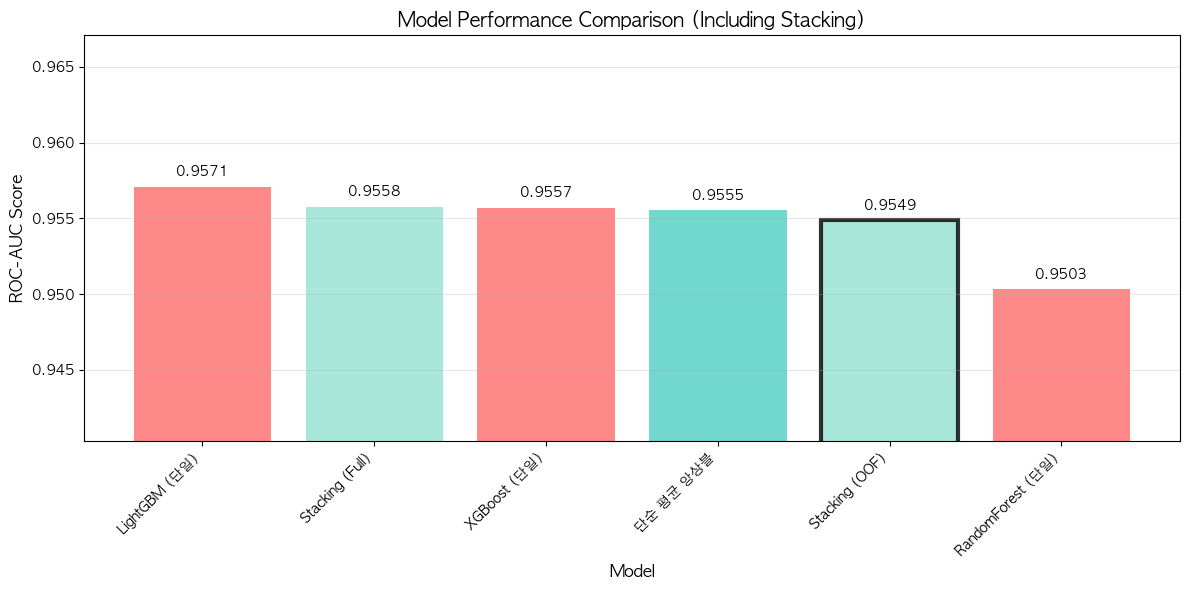

✓ 시각화 완료


In [32]:

# -----------------------------------------------------------------------------
# 7단계: 시각화
# -----------------------------------------------------------------------------

print("\n7단계: 성능 시각화...")

import matplotlib.pyplot as plt
import seaborn as sns

# 성능 비교 바 차트
plt.figure(figsize=(12, 6))

colors = ['#FF6B6B' if t == '단일' else '#4ECDC4' if t == 'Voting' else '#95E1D3' 
          for t in results['Type']]

bars = plt.bar(range(len(results)), results['ROC-AUC'], color=colors, alpha=0.8)

# Stacking (OOF) 강조
stacking_idx = results[results['Model'] == 'Stacking (OOF)'].index[0]
bars[stacking_idx].set_edgecolor('black')
bars[stacking_idx].set_linewidth(3)

plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('ROC-AUC Score', fontsize=12, fontweight='bold')
plt.title('Model Performance Comparison (Including Stacking)', fontsize=14, fontweight='bold')
plt.xticks(range(len(results)), results['Model'], rotation=45, ha='right')
plt.ylim([results['ROC-AUC'].min() - 0.01, results['ROC-AUC'].max() + 0.01])

# 값 표시
for i, (idx, row) in enumerate(results.iterrows()):
    plt.text(i, row['ROC-AUC'] + 0.0005, f"{row['ROC-AUC']:.4f}", 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ 시각화 완료")


In [36]:
print("\n" + "=" * 60)
print("7. 최종 예측 및 제출 파일 생성")
print("=" * 60)

# =============================================================================
# 0. Sample Submission 로드 및 확인
# =============================================================================

print("\n0️⃣ Sample Submission 파일 로드...")
submission_template = pd.read_csv('../data/sample_submission.csv')

print(f"✓ 로드 완료: {submission_template.shape}")
print(f"  컬럼: {list(submission_template.columns)}")
print(f"  데이터 타입:\n{submission_template.dtypes}")
print(f"\n샘플:\n{submission_template.head()}")

# 컬럼명 자동 인식
id_column = submission_template.columns[0]
pred_column = submission_template.columns[1]

print(f"\nID 컬럼: '{id_column}'")
print(f"예측값 컬럼: '{pred_column}'")

# =============================================================================
# 1. 개별 모델 예측 및 제출 파일 생성
# =============================================================================

print("\n1️⃣ 개별 모델 예측 중...\n")

# XGBoost
print("  XGBoost 예측 중...", end=" ")
xgb_test_proba = final_xgb.predict_proba(test_df)[:, 1]
submission_xgb = submission_template.copy()
submission_xgb[pred_column] = xgb_test_proba
submission_xgb.to_csv('submission_xgb.csv', index=False)
print("✓")

# LightGBM
print("  LightGBM 예측 중...", end=" ")
lgbm_test_proba = final_lgbm.predict_proba(test_df)[:, 1]
submission_lgbm = submission_template.copy()
submission_lgbm[pred_column] = lgbm_test_proba
submission_lgbm.to_csv('submission_lgbm.csv', index=False)
print("✓")

# RandomForest
print("  RandomForest 예측 중...", end=" ")
rf_test_proba = final_rf.predict_proba(test_df)[:, 1]
submission_rf = submission_template.copy()
submission_rf[pred_column] = rf_test_proba
submission_rf.to_csv('submission_rf.csv', index=False)
print("✓")

# =============================================================================
# 2. Stacking
# =============================================================================

print("\n2️⃣ Stacking 앙상블 예측 중...\n")

print("  Stacking 예측 중...", end=" ")
stacking_test_proba = final_stacking.predict_proba(test_df)[:, 1]
submission_stacking = submission_template.copy()
submission_stacking[pred_column] = stacking_test_proba
submission_stacking.to_csv('submission_stacking.csv', index=False)
print("✓")

# =============================================================================
# 3. 생성 확인
# =============================================================================

print("\n" + "=" * 60)
print("📁 생성된 파일")
print("=" * 60)

import os
for fname in ['submission_xgb.csv', 'submission_lgbm.csv', 
              'submission_rf.csv', 'submission_stacking.csv']:
    if os.path.exists(fname):
        size_kb = os.path.getsize(fname) / 1024
        print(f"✅ {fname:25s} ({size_kb:.2f} KB)")

# =============================================================================
# 4. 예측값 확인
# =============================================================================

print("\n" + "=" * 60)
print("📊 예측 샘플 (처음 10개)")
print("=" * 60)

comparison_df = pd.DataFrame({
    id_column: submission_template[id_column].head(10),
    'XGBoost': xgb_test_proba[:10],
    'LightGBM': lgbm_test_proba[:10],
    'RandomForest': rf_test_proba[:10],
    'Stacking': stacking_test_proba[:10]
})

print("\n" + comparison_df.to_string(index=False))

print("\n" + "=" * 60)
print("✅ 제출 파일 생성 완료!")
print("=" * 60)


7. 최종 예측 및 제출 파일 생성

0️⃣ Sample Submission 파일 로드...
✓ 로드 완료: (270000, 2)
  컬럼: ['id', 'Heart Disease']
  데이터 타입:
id               int64
Heart Disease    int64
dtype: object

샘플:
       id  Heart Disease
0  630000              0
1  630001              0
2  630002              0
3  630003              0
4  630004              0

ID 컬럼: 'id'
예측값 컬럼: 'Heart Disease'

1️⃣ 개별 모델 예측 중...

  XGBoost 예측 중... ✓
  LightGBM 예측 중... ✓
  RandomForest 예측 중... ✓

2️⃣ Stacking 앙상블 예측 중...

  Stacking 예측 중... ✓

📁 생성된 파일
✅ submission_xgb.csv        (4740.28 KB)
✅ submission_lgbm.csv       (7021.32 KB)
✅ submission_rf.csv         (6968.50 KB)
✅ submission_stacking.csv   (6990.88 KB)

📊 예측 샘플 (처음 10개)

    id  XGBoost  LightGBM  RandomForest  Stacking
630000 0.948212  0.940181      0.676293  0.924649
630001 0.007499  0.008148      0.031979  0.037054
630002 0.988582  0.975163      0.923265  0.959178
630003 0.004443  0.006421      0.026920  0.036306
630004 0.228120  0.228967      0.432722  0.193323
630005 